# Granite based on local behavior (effects) for Bike Rental Predictions

This notebook leverages GRANITE to yield regional explanations on the BikeSharing dataset using local effects. We first look at minimizing disagreement due to interactions (pure vs. full) and then to minimize disagreement due to distributional influence (marginal vs. conditional)


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from joblib import dump, load

# Local imports
from granite.data import get_data_bike
from granite.decompositions import get_components_brute_force, get_regional_decompositions

/home/gabriel/anaconda3/envs/GRANITE/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [3]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_bike()
# Make months and weekdays smaller for the plots (optional)
features.feature_objs[1].cats = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
features.feature_objs[4].cats = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
features.summary()
cat_features = [0, 1, 3, 4, 5, 6]

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | yr                 | ordinal            | 2          | [0]              |
| 1 | mnth               | ordinal            | 12         | [1]              |
| 2 | hr                 | num_int            | 24         | [2]              |
| 3 | holiday            | bool               | 2          | [3]              |
| 4 | weekday            | ordinal            | 7          | [4]              |
| 5 | workingday         | bool               | 2          | [5]              |
| 6 | weathersit         | num_int            | 4          | [6]              |
| 7 | temp               | num                | inf        | [7]              |
| 8 | hum                | num                | inf        | [8]              |
| 9 | windspeed          | num                | inf        | [9]              |
----------------------------------------

This dataset involves 10 features of various types. The following Table can help understand their meaning and domain.

<p align="center">
    <img src="./Images/Features_bike.png" width="600">
</p>

### Fitting the model
Having fetched the data, we fit a `HistGradientBoostingRegressor`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

**Do not run the following cells if you have already trained the model. Skip to later cells.**

In [4]:
grid = {"learning_rate": np.logspace(-2, 0, 10),
        "max_depth" : [3, 4, 5, 6, 7],
        "max_iter" : [50, 100, 150, 200],
        'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

search = RandomizedSearchCV(
    model,
    cv=KFold(),
    scoring='neg_root_mean_squared_error',
    param_distributions=grid,
    verbose=2,
    n_iter=20,
    random_state=42
)
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.3s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.3s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.3s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.3s
[CV] END learning_rate=1.0, max_depth=7, max_iter=50, min_samples_leaf=40; total time=   0.5s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.2s
[CV] END learning_rate=0.3593813663804626, max_depth=4, max_iter=50, min_samples_leaf=20; total time=   0.1s
[CV] END learning_rate=0.3593813

,estimator,HistGradientB...andom_state=0)
,param_distributions,"{'learning_rate': array([0.01 ..., 1. ]), 'max_depth': [3, 4, ...], 'max_iter': [50, 100, ...], 'min_samples_leaf': [1, 20, ...]}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [5]:
# Recover the optimal CV model
model = search.best_estimator_
res = search.cv_results_
cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
best_idx = np.argmin(cv_perf)

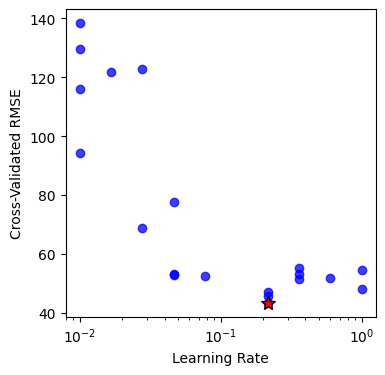

In [6]:
plt.figure(figsize=(4, 4))
plt.scatter(res['param_learning_rate'], cv_perf, c='b', alpha=0.75)
plt.plot(res['param_learning_rate'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validated RMSE")
plt.xscale('log')
plt.show()

In [7]:
# Pickle the model
dump(model, os.path.join("models", "bike_gbt.joblib"))

['models/bike_gbt.joblib']

**Start from here if you have already trained and dumped the model.**

In [8]:
# Load the model
model = load(os.path.join("models", "bike_gbt.joblib"))
test_preds = model.predict(X_test)
print(f" RMSE of the model : {root_mean_squared_error(test_preds, y_test):.2f}")
print(f" Std dev of the target : {y_test.std():.2f}")

 RMSE of the model : 43.08
 Std dev of the target : 181.45


## Disagreement due to interactions: Marginal Pure-Full Effects (individual feature influence)

We can understand how an individual features impact the model response by computing their pure and full marginal effects.
We first compute the Anchored decomposition.

In [9]:
from granite.decompositions import get_components_tree
# Compute the H^k matrices using a subset of 1000 training points
background = X_test[:1000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)

[                                                  ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #          

#     ] 90#     ] 90#     ] 90#     ] 90#     ] 90#     ] 90#     ] 90919#    ] 9#    ] 9#    ] 9#    ] 9#    ] 9#    ] 9#    ] 9#    ] 9#    ] 9#    ] 929394#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94959#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 969798# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 9899100#] 100%

In [10]:
# The keys are tuples encoding subsets of features
display(decomposition.keys())
# The () key is the intercept
display(decomposition[()].shape)
# The key (i,) is the main effect of feature i in the Anchored Decomposition
display(decomposition[(0,)].shape)

dict_keys([(), (0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,), (9,)])

(1000,)

(1000, 1000)

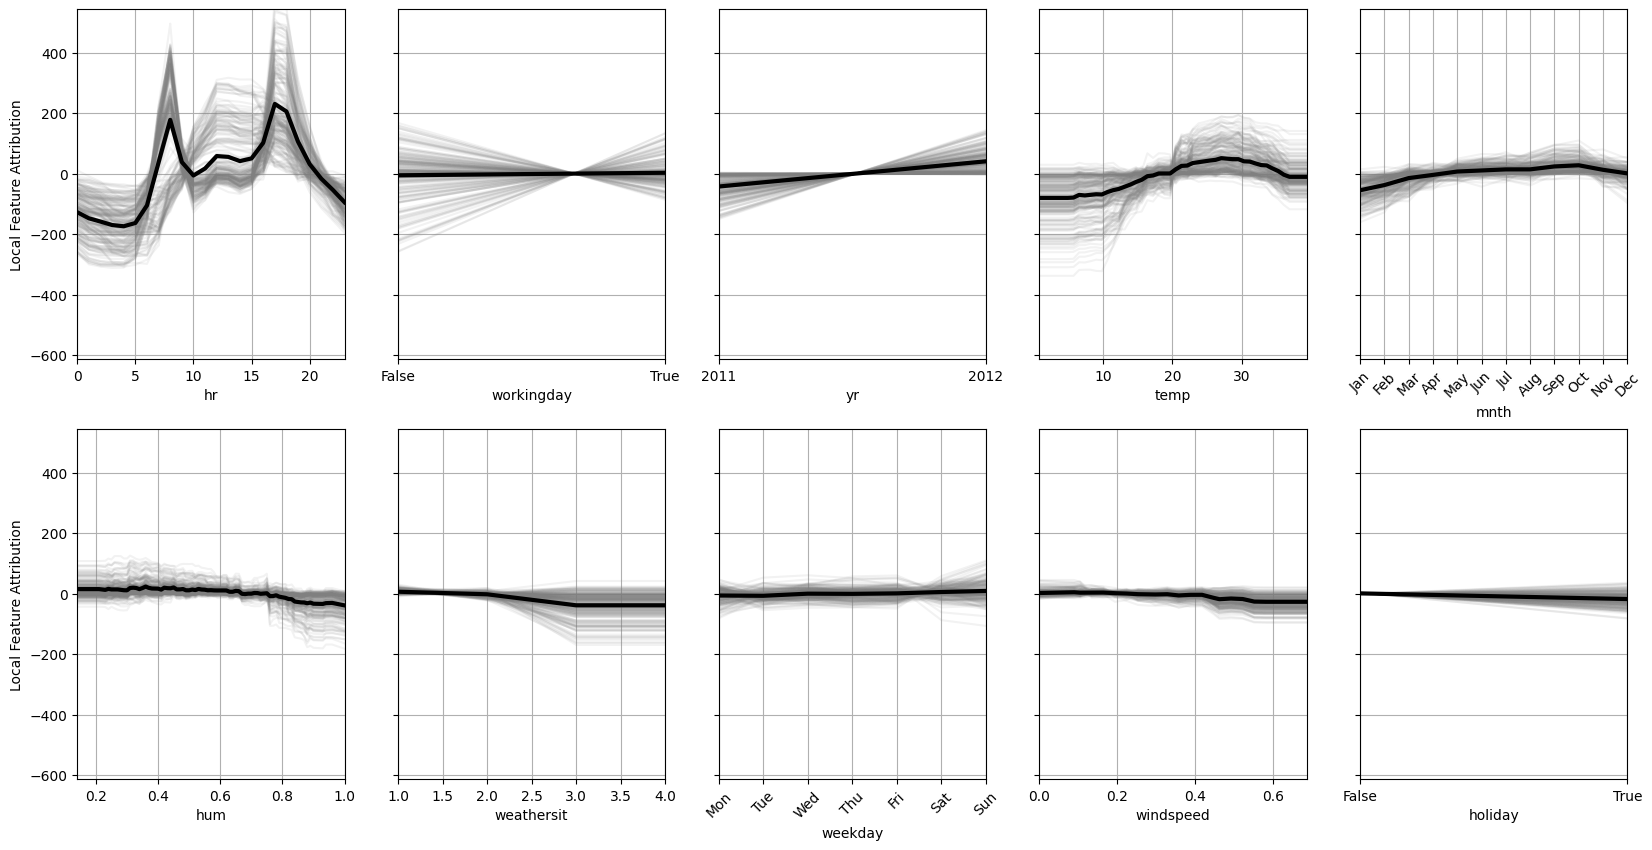

In [12]:
from granite.plots import partial_dependence_plot, set_ticks_categorical_features

# Plot the PDP and the ICE curves
partial_dependence_plot(decomposition, background, features, centered=True, figsize=(20, 10), n_cols=5)
plt.savefig("../figures/bike_pure_full_global_all.pdf", bbox_inches="tight")

plt.show()

# Save the entire figure (all selected plots) as a PDF
#import matplotlib.pyplot as plt
#plt.savefig("../figures/bike_pure_full_global.pdf", bbox_inches="tight")
#plt.close()

**Hour and temperature have the highers heterogeneity (besides workingday)**

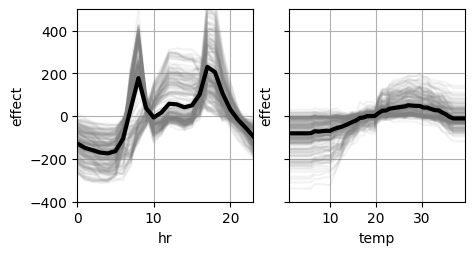

In [12]:
from granite.plots import partial_dependence_plot

# Plot the PDP and the ICE curves
fig, ax = partial_dependence_plot(decomposition, background, features, idxs = [2, 7], centered=True, figsize=(5, 2.5))

# If ax is an array, iterate over it
if isinstance(ax, np.ndarray):
    for a in ax.ravel():
        a.set_ylim(-400, 500)
        a.set_ylabel("effect")
else:
    ax.set_ylim(-400, 500)
    ax.set_ylabel("effect")



plt.savefig("../figures/bike_pure_full_global_main.pdf", bbox_inches='tight', dpi=300)
plt.show()
# Save the entire figure (all selected plots) as a PDF
##import matplotlib.pyplot as plt
#plt.savefig("../figures/bike_pure_full_global_main.pdf", bbox_inches="tight")  # tight layout
#plt.close()  # closes the figure to free memory

**We now perform GRANITE to minimize interactions from full to pure fo individual local effects of all features.**

In [13]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

# Option 1: We minimize all interactions
U = [(i,) for i in range(len(features))]
features_to_split_upon = [i for i in range(len(features))]

# # Option 2: We minimize all interactions involving `temp`
# U = [(7,)]
# features_to_split_upon = [i for i in range(len(features)) if not i == 7]

# We penalize all pure-vs-full effects of each feature, which ammounts to minimizing all interactions within the model
loss_fn = get_marginal_pure_vs_full_loss_fn(
    decomposition=decomposition,
    U=U
)
tree = FDTree(max_depth=3, features=features.select(features_to_split_upon), alpha=0.1, save_losses=True)
tree.fit(background[:, features_to_split_upon], loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.1735
|   Samples 341
|   Region 0
else:
|   Loss 0.3587
|   Samples 659
|   If hr ≤ 6.0000:
|   |   Loss 0.0044
|   |   Samples 189
|   |   Region 1
|   else:
|   |   Loss 0.2285
|   |   Samples 470
|   |   Region 2
Final Loss 0.4064


In [14]:
# Using regional backgrounds
larger_background = X_test
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

(array([0, 1, 2], dtype=int32), array([1121,  690, 1665]))
{0: 'not workingday', 1: '(workingday & hr<=6.00)', 2: '(workingday & hr>6.00)'}


In [15]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_shap = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    anchored=True
                                                )

[                                                  ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #          

[                                                  ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] 4#                                                ] 4#                                                ] 4#                                                ] 4#                                                ] 4#         

[                                                  ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ] #                                                 ] #          

#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94#   ] 94959#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 969798# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 9899100#] 100%

**We plot the regional effects for all features -- disagreement is highly reduced, however, there seems to be still some left, particularly in temperature and in hour**

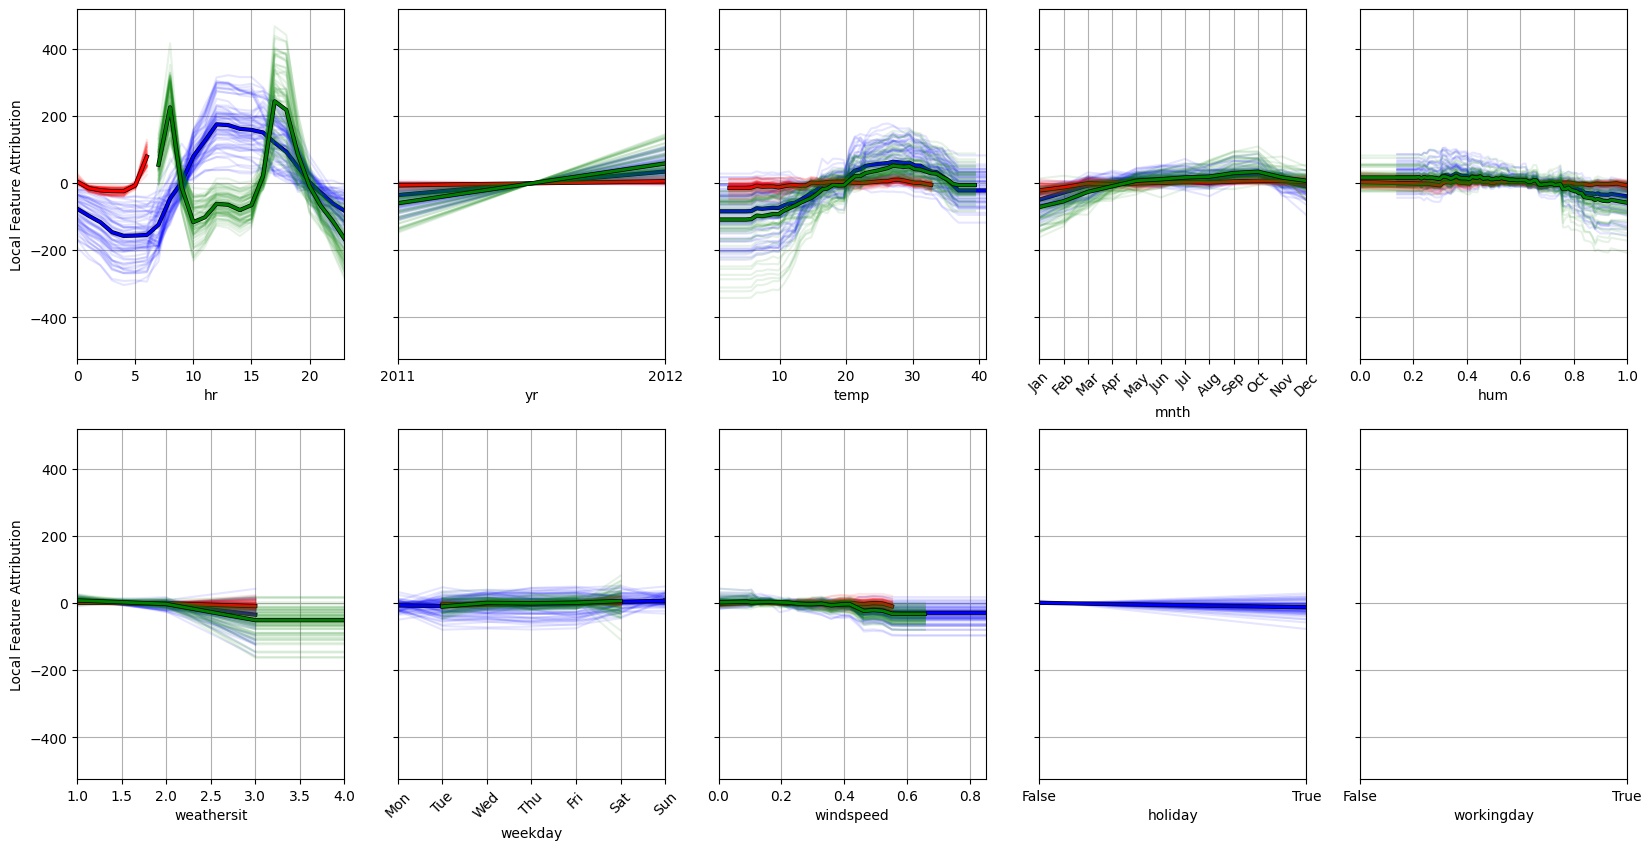

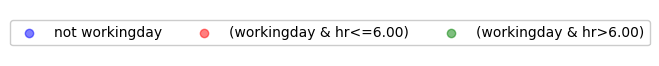

In [17]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, centered=True, figsize=(20, 10), n_cols=5)
plt.savefig("../figures/bike_pure_full_regional_all.pdf", bbox_inches='tight')

plot_legend(rules, ncol=4)
plt.savefig("../figures/bike_pure_full_regional_all_legend.pdf", bbox_inches='tight')

plt.show()

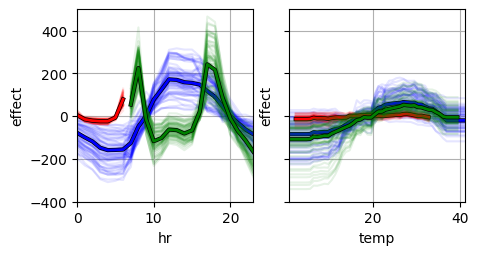

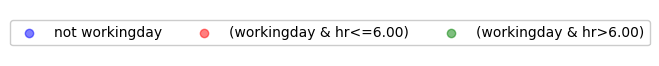

In [17]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
fig, ax = partial_dependence_plot(regional_decomposition, regional_backgrounds, features, idxs = [2, 7], centered=True, figsize=(5, 2.5), n_cols = 2)


# TODO: adjust ax and fig if necessary here
# If ax is an array, iterate over it
if isinstance(ax, np.ndarray):
    for a in ax.ravel():
        a.set_ylim(-400, 500)
        a.set_ylabel("effect")
else:
    ax.set_ylim(-400, 500)
    ax.set_ylabel("effect")
plt.savefig("../figures/bike_pure_full_regional_main.pdf", bbox_inches='tight')

plot_legend(rules, ncol=4)
plt.savefig("../figures/bike_pure_full_regional_main_legend.pdf", bbox_inches='tight')

plt.show()

**We split on depth deeper and see that disagreement is further reduced**

In [18]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

# Option 1: We minimize all interactions
U = [(i,) for i in range(len(features))]
features_to_split_upon = [i for i in range(len(features))]

# # Option 2: We minimize all interactions involving `temp`
# U = [(7,)]
# features_to_split_upon = [i for i in range(len(features)) if not i == 7]

# We penalize all pure-vs-full effects of each feature, which ammounts to minimizing all interactions within the model
loss_fn = get_marginal_pure_vs_full_loss_fn(
    decomposition=decomposition,
    U=U
)
tree = FDTree(max_depth=4, features=features.select(features_to_split_upon), alpha=0.05, save_losses=True)
tree.fit(background[:, features_to_split_upon], loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.1735
|   Samples 341
|   If hr ≤ 7.0000:
|   |   Loss 0.0061
|   |   Samples 115
|   |   Region 0
|   else:
|   |   Loss 0.0917
|   |   Samples 226
|   |   Region 1
else:
|   Loss 0.3587
|   Samples 659
|   If hr ≤ 6.0000:
|   |   Loss 0.0044
|   |   Samples 189
|   |   Region 2
|   else:
|   |   Loss 0.2285
|   |   Samples 470
|   |   If yr ≤ 0.0000:
|   |   |   Loss 0.0529
|   |   |   Samples 233
|   |   |   Region 3
|   |   else:
|   |   |   Loss 0.0948
|   |   |   Samples 237
|   |   |   Region 4
Final Loss 0.2498


In [19]:
# Using regional backgrounds
larger_background = X_test[:3000]
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

(array([0, 1, 2, 3, 4], dtype=int32), array([334, 632, 592, 722, 720]))
{0: '(not workingday & hr<=7.00)', 1: '(not workingday & hr>7.00)', 2: '(workingday & hr<=6.00)', 3: '(workingday & hr>6.00 & yr=2011)', 4: '(workingday & hr>6.00 & yr=2012)'}


In [20]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_shap = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(model,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    anchored=True
                                                )

[##################################################] 100%[#                                                 ] 2%

##################################################] 100%[                                        

##################################################] 100%[                                                  ] 0%

##################################################] 100%[                                                  ] 0%

############################################      ] 89%

######] 100%

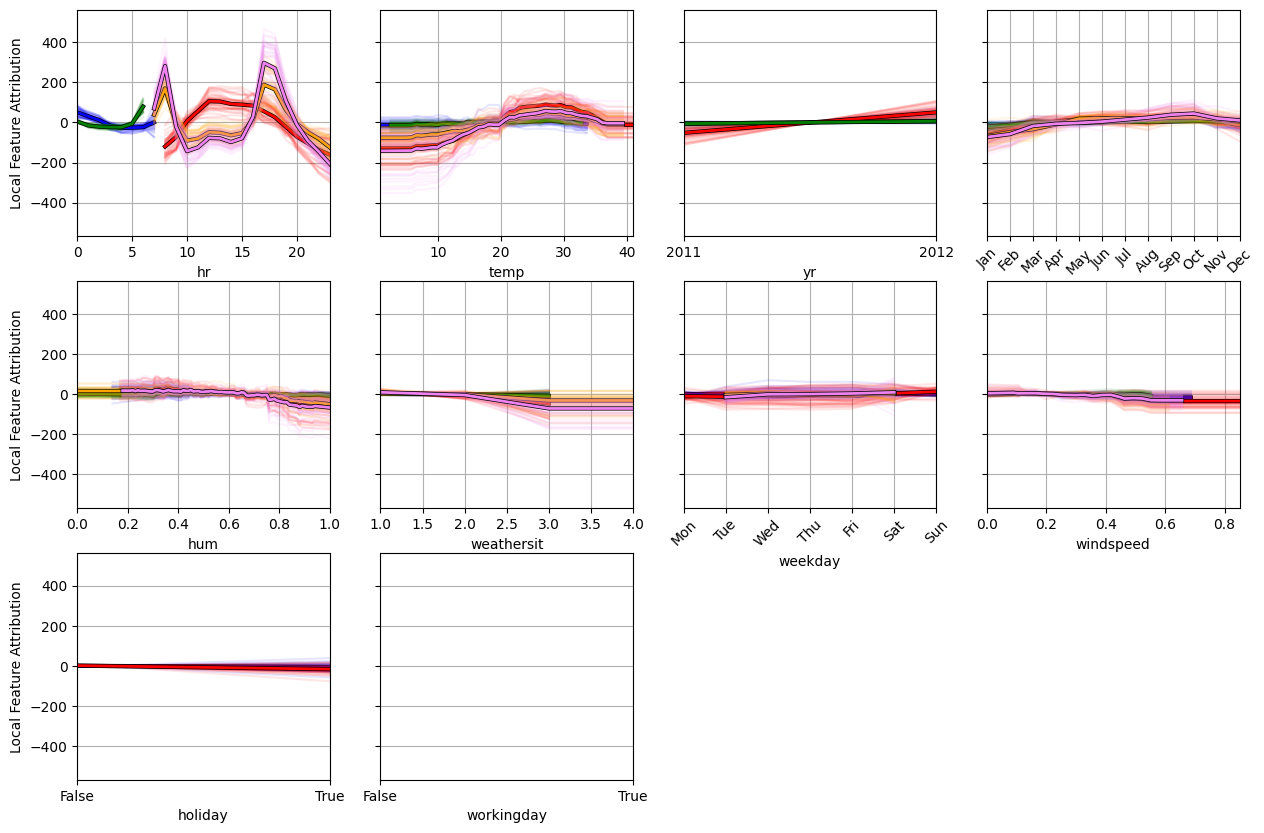

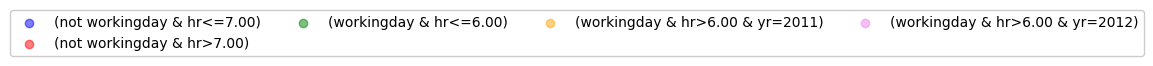

In [21]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, centered=True, figsize=(15, 10), n_cols = 4)
plt.savefig("../figures/bike_pure_full_regional_all_deep.pdf", bbox_inches='tight')

plt.show()

plot_legend(rules, ncol=4)
plt.savefig("../figures/bike_pure_full_regional_all_deep_legend.pdf", bbox_inches='tight')

plt.show()

## Pure vs. Full for Interaction influence measures

**We were able to reduce the disagreement between hour and temperature a bit more by splitting deeper, however, such interactions between numeric features are more difficult to handle with paritioning since we need many splits. Instead we now focus only on higher-order interactions than order 2 of features hour and termperature. Since we are still able to visualize 2nd order interactions, this remains interpretable with reduced number of regions.

In [22]:
# Compute the H^k matrices using a subset of 1000 training points
background = X_test[:1000]

# Compute the Interventional Decomposition
decomposition = get_components_brute_force(
    lambda X: model.predict(X),  # use predict instead of calling the model directly
    background,
    background,
    features,
    interactions=2,
    show_bar=True
)
display(decomposition.keys())

Functional Decomposition: 10it [00:01,  6.77it/s]
Functional Decomposition: 45it [04:15,  5.68s/it]


dict_keys([(), (0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,), (9,), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 6), (5, 7), (5, 8), (5, 9), (6, 7), (6, 8), (6, 9), (7, 8), (7, 9), (8, 9)])

In [23]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

# We minimize the pure-full interactions involving features x0 and x1
loss_fn = get_marginal_pure_vs_full_loss_fn(
    decomposition=decomposition,
    U=[(2, 7)]
)
features_to_split_upon = [0, 1, 3, 4, 5, 6, 8, 9]
tree = FDTree(features.select(features_to_split_upon), max_depth=1, save_losses=True, branching_per_node=2, alpha=0.1)
tree.fit(background[:, features_to_split_upon], loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.1520
|   Samples 341
|   Region 0
else:
|   Loss 0.2418
|   Samples 659
|   Region 1
Final Loss 0.3937


In [24]:
# Using regional backgrounds
larger_background = X_test[:3000]
regions = tree.predict(larger_background[:, features_to_split_upon])
display(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
display(rules)
#regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
#regional_backgrounds = [[]] * n_regions
#for r in range(tree.n_regions):
#    regional_backgrounds[r] = background[regions == r]

array([1, 1, 1, 0, 1, 1, 0, 1, 1, 1], dtype=int32)

{0: 'not workingday', 1: 'workingday'}

In [25]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_shap = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_brute_force(lambda X: model.predict(X),  # use predict instead of calling the model directly
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    interactions=2
                                                )

In [26]:
regional_decomposition

[{(): array([ 8.31963708e+01,  2.01196451e+02,  6.17095021e+00,  3.83734208e+02,
          9.10552526e+01,  2.65766246e+02,  1.12226380e+02,  4.90706704e+00,
          5.53316290e+02,  5.30782470e+01,  1.77644162e+02,  1.46926988e+02,
          2.92256862e+02,  1.90095814e+02,  6.02244530e+01,  2.02663100e+02,
          7.40972043e+01,  9.49172796e+01,  3.84724475e+02,  1.14712528e+02,
          1.10657481e+02,  9.62256151e+01,  8.00522317e+01,  4.41291632e+02,
          2.94658663e+02,  1.60433690e+02,  6.52929067e+01,  2.70422448e+02,
          4.89021684e+02, -6.25666737e+00,  3.31750864e+02,  1.75268438e+02,
          6.77077268e+00,  9.99677868e+00,  1.63328957e+02,  3.18253458e+02,
          3.13467420e+02,  3.18310784e+02,  2.68144083e+02,  1.96129310e+02,
          5.27844197e+02,  1.62463845e+02, -1.50486554e+00,  8.14764445e+01,
          2.39464520e+02,  1.59578456e+01,  1.79324248e+02,  1.08927086e+02,
          1.82637485e+01,  1.05434055e+02,  2.17987721e+02,  2.22473263e

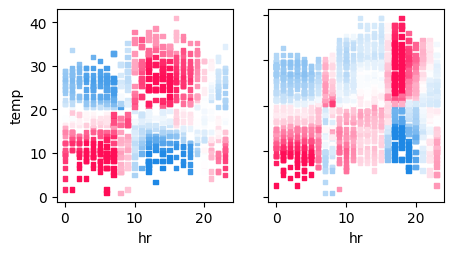

In [30]:
from matplotlib.colors import CenteredNorm
from granite.plots import get_red_white_blue_cmap

cmap = get_red_white_blue_cmap()

n_regions = tree.n_regions
# Regional h_i and SHAP values
max_abs_val = max(*[np.abs(regional_decomposition[r][(2, 7)].mean(-1)).max() for r in range(n_regions)])
fig, axs = plt.subplots(1, n_regions, figsize=(5, 2.5))
for r in range(n_regions):
    sc = axs[r].scatter(
        regional_backgrounds[r][:, 2],  # x-axis
        regional_backgrounds[r][:, 7],  # y-axis
        c=regional_decomposition[r][(2, 7)].mean(-1),
        s=10,
        marker="s",
        cmap=cmap,
        norm=CenteredNorm(0, halfrange=max_abs_val)
    )
    axs[r].set_xlabel("hr")

    # ✅ Set ylabel only on the first suÏbplot
    if r == 0:
        axs[r].set_ylabel("temp")
    else:
        axs[r].set_ylabel("")             # remove text
        axs[r].tick_params(labelleft=False)  # hide tick labels too

    #axs[r].set_title(rules[r])

# fig.colorbar(cmap, ax=axs[r])


plt.savefig("../figures/bike_pure_full_interaction_regional.pdf", bbox_inches='tight')
plt.show()


## Disagreement due to distribution: Conditional vs. Marginal Pure Effects (individual feature influence)



In [18]:
# create bins for all features
from granite.utils import create_bins_for_data

_, binned_features = create_bins_for_data(
    x=background,
    cat_feature_indices=cat_features,
    n_bins_numerical=5,
)

for i, bins in enumerate(binned_features):
    print(f"Feature {i}: Binned Indices Sample = {binned_features[i][:10]}")


Feature 0: Binned Indices Sample = [0 0 0 0 0 0 0 0 0 0]
Feature 1: Binned Indices Sample = [ 5  4 10  0  2  8  8 10  3  1]
Feature 2: Binned Indices Sample = [1 0 3 2 0 4 4 0 0 1]
Feature 3: Binned Indices Sample = [0 0 0 0 0 0 0 0 0 0]
Feature 4: Binned Indices Sample = [1 2 4 1 3 4 5 3 1 2]
Feature 5: Binned Indices Sample = [0 0 0 0 0 0 0 0 0 0]
Feature 6: Binned Indices Sample = [1 0 0 1 0 1 1 1 0 0]
Feature 7: Binned Indices Sample = [3 4 1 0 2 4 3 2 3 0]
Feature 8: Binned Indices Sample = [3 3 1 1 2 1 4 4 4 2]
Feature 9: Binned Indices Sample = [2 2 3 2 1 2 2 4 1 0]


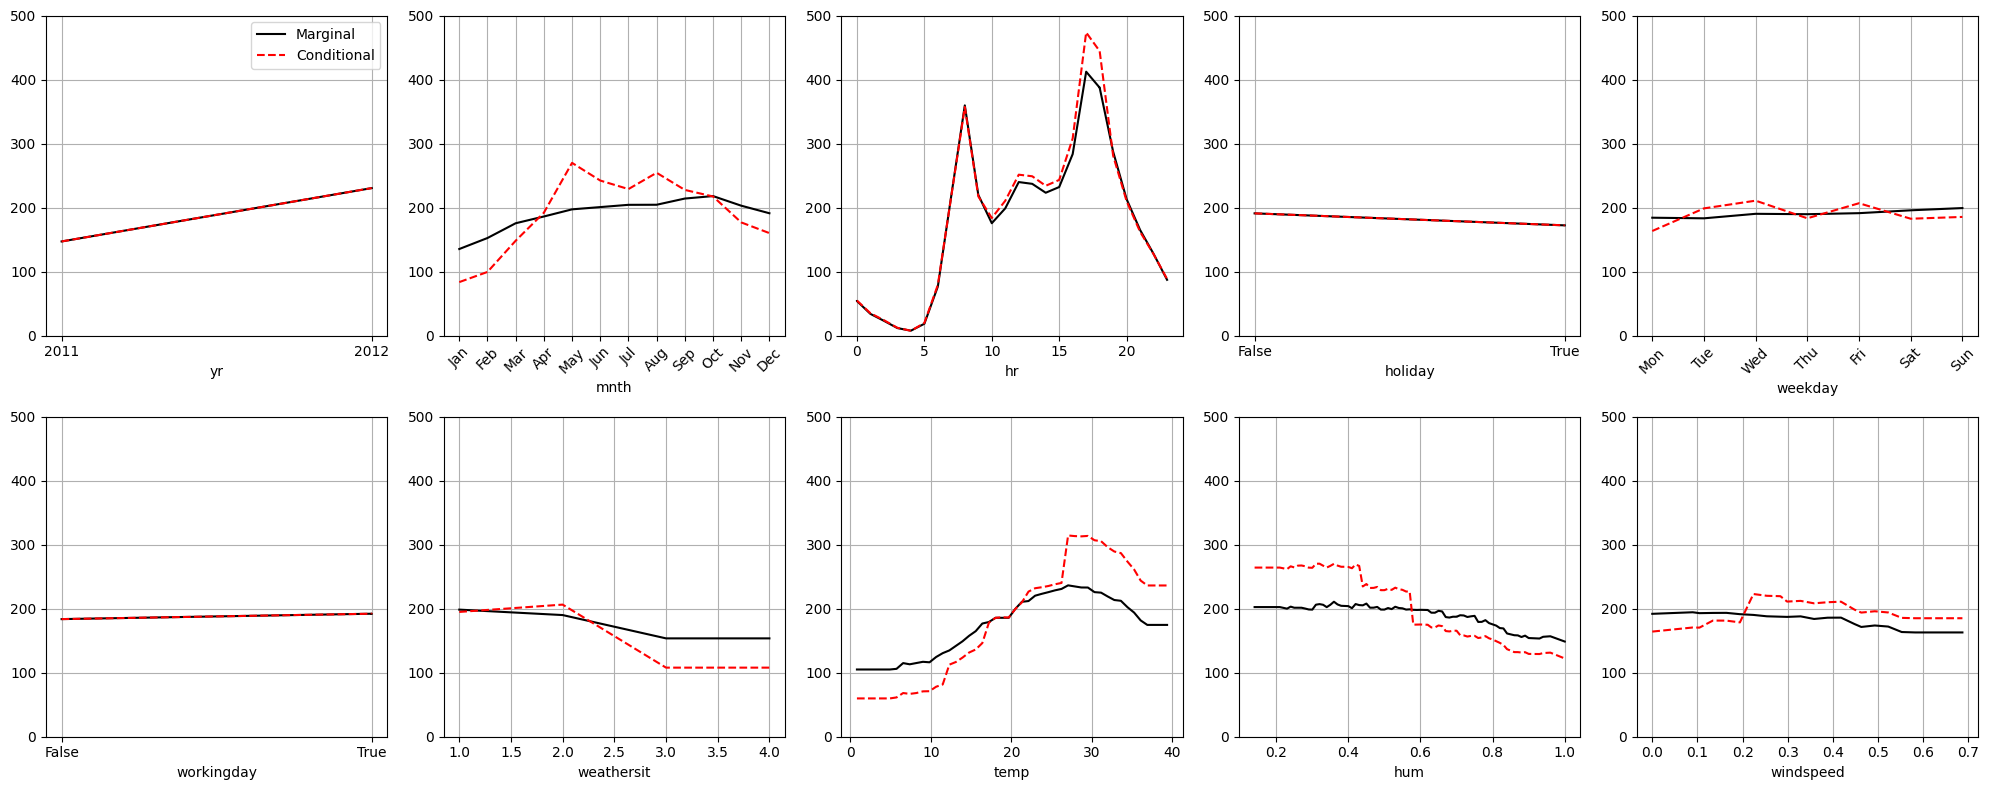

In [25]:
from math import ceil
from granite.experiments import get_marginal_conditional_effects
from granite.utils import decomposition_to_R

R = decomposition_to_R(decomposition)

n_features = 10
n_cols = 5
n_rows = ceil(n_features / n_cols)
ylim = (0, 500)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()  # flatten to make indexing easier

for i, feature_id in enumerate(range(n_features)):
    marginal_effect, conditional_effect = get_marginal_conditional_effects(
        binned_features[feature_id],
        R[(feature_id,)]
    )
    argsort_x_i = np.argsort(background[:, feature_id])

    ax = axes[i]  # pick the subplot for this feature
    ax.plot(background[argsort_x_i, feature_id], marginal_effect[argsort_x_i], 'k-', label="Marginal")
    ax.plot(background[argsort_x_i, feature_id], conditional_effect[argsort_x_i], 'r--', label="Conditional")

    feature_obj = features.feature_objs[feature_id]

    # Set categorical ticks if applicable
    if feature_obj.type in ["bool", "ordinal", "nominal"]:
        set_ticks_categorical_features(ax, feature_obj, cat_name_threshold=10, degree=45)
    ax.set_xlabel(feature_obj.name)

    ax.grid('on')
    ax.set_ylim(*ylim)
    if i == 0:
        ax.legend()

# Turn off any unused axes
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

plt.savefig("../figures/bike_marg_cond_global_all.pdf", bbox_inches='tight')

plt.show()


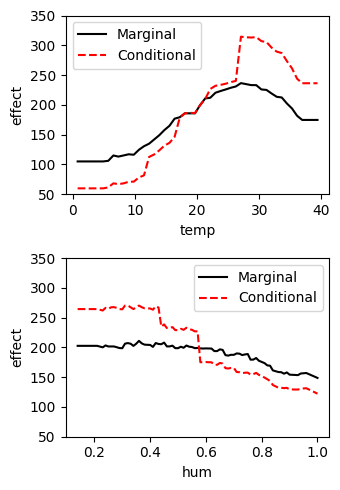

In [46]:
from math import ceil
from granite.experiments import get_marginal_conditional_effects
from granite.utils import decomposition_to_R

R = decomposition_to_R(decomposition)

# Specify which features to plot
feature_ids_to_plot = [7, 8]  # example: only features 0 and 3
n_features = len(feature_ids_to_plot)

n_cols = 1  # adjust number of columns
n_rows = ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5, 5))
axes = axes.flatten()  # flatten to make indexing easier

for i, feature_id in enumerate(feature_ids_to_plot):
    marginal_effect, conditional_effect = get_marginal_conditional_effects(
        binned_features[feature_id],
        R[(feature_id,)]
    )
    argsort_x_i = np.argsort(background[:, feature_id])

    ax = axes[i]  # pick the subplot for this feature
    ax.plot(background[argsort_x_i, feature_id], marginal_effect[argsort_x_i], 'k-', label="Marginal")
    ax.plot(background[argsort_x_i, feature_id], conditional_effect[argsort_x_i], 'r--', label="Conditional")

    feature_obj = features.feature_objs[feature_id]

    # Set categorical ticks if applicable
    if feature_obj.type in ["bool", "ordinal", "nominal"]:
        set_ticks_categorical_features(ax, feature_obj, cat_name_threshold=10, degree=45)
    else:
        ax.set_xlabel(feature_obj.name)
        ax.set_ylabel("effect")

    ax.set_ylim(50, 350)
    ax.legend()

# Turn off any unused axes
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

plt.savefig("../figures/bike_marg_cond_global_main.pdf", bbox_inches='tight')
plt.show()


In [26]:
from granite.experiments import get_marginal_vs_conditional_pure_loss_fn


loss_fn = get_marginal_vs_conditional_pure_loss_fn(
    decomposition=decomposition,
    U = [(i,) for i in range(len(features))],
    #U=[(feature_id,)],
    binned_features=[binned_features[i] for i in range(len(features))]
)
features_to_split_upon = [i for i in range(len(features))]
tree = FDTree(
    features.select(features_to_split_upon), 
    max_depth=2,
    save_losses=True, 
    branching_per_node=3, 
    alpha=0.05
)
tree.fit(background[:, features_to_split_upon], loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If hr ≤ 6.0000:
|   Loss 0.0144
|   Samples 291
|   Region 0
else:
|   Loss 0.6673
|   Samples 709
|   If temp ≤ 16.4000:
|   |   Loss 0.0774
|   |   Samples 239
|   |   Region 1
|   else:
|   |   Loss 0.3159
|   |   Samples 470
|   |   Region 2
Final Loss 0.4077


In [27]:
larger_background = X_test
_, binned_features = create_bins_for_data(
    x=larger_background,
    cat_feature_indices=cat_features,
    n_bins_numerical=5,
)
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()

(array([0, 1, 2], dtype=int32), array([1036,  814, 1626]))


In [28]:
regional_decompositions = [[]] * tree.n_regions
regional_backgrounds = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions == r]
    regional_decompositions[r] = get_components_tree(model, regional_backgrounds[r], regional_backgrounds[r], features, anchored=True)

[                                                  ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #          

                                                  ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] #                                                 ] 4#                                                ] 4#                                                ] 4#                                                ] 4#                                                ] 4#          

                                                  ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ]                                                   ] #                                                 ] #                                                 ] #                                                 ] #           

#   ] 94959#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 9#  ] 969798# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 98# ] 9899100#] 100%

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from math import ceil

def plot_regional_mplot_pdp(
    regional_decompositions,
    regional_backgrounds,
    binned_features,
    background,
    features,
    rules,
    n_cols=4,
    cat_name_threshold=10,
    feature_idxs=None,
    figsize=None,  # ✅ New parameter
    ylim: tuple[float, float] | None = None # ✅ New parameter
):
    if feature_idxs is None:
        feature_idxs = list(range(len(features)))
    n_features = len(feature_idxs)
    n_rows = ceil(n_features / n_cols)

    # ✅ Use user-provided figsize or default fallback
    if figsize is None:
        figsize = (5 * n_cols, 4 * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    # Color palette for regions
    colors = plt.cm.tab10.colors

    for i, feature_id in enumerate(feature_idxs):
        ax = axes[i]
        feature_obj = features.feature_objs[feature_id]

        # x-range for numeric features
        x_min, x_max = background[:, feature_id].min(), background[:, feature_id].max()

        for r in range(len(regional_decompositions)):
            R = regional_decompositions[r][(feature_id,)] + regional_decompositions[r][()]
            marginal_effect, conditional_effect = get_marginal_conditional_effects(
                binned_features[feature_id][regions == r], R
            )
            X_region = regional_backgrounds[r]
            argsort_x_i = np.argsort(X_region[:, feature_id])
            color = colors[r % len(colors)]

            # Marginal = solid
            ax.plot(
                X_region[argsort_x_i, feature_id],
                marginal_effect[argsort_x_i],
                linestyle='-',
                color=color
            )
            # Conditional = dashed
            ax.plot(
                X_region[argsort_x_i, feature_id],
                conditional_effect[argsort_x_i],
                linestyle='--',
                color=color
            )

        # Handle categorical features
        if feature_obj.type in ["bool", "ordinal", "nominal"]:
            set_ticks_categorical_features(ax, feature_obj, cat_name_threshold=10, degree=45)
        else:
            ax.set_xlim(x_min, x_max)

        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_xlabel(feature_obj.name)
        ax.set_ylabel("")
        ax.grid('on')

    # Remove unused subplots
    for i in range(n_features, n_rows * n_cols):
        fig.delaxes(axes[i])

    # Shared legend for marginal vs conditional
    style_handles = [
        plt.Line2D([0], [0], color='black', linestyle='-', lw=2, label='Marginal'),
        plt.Line2D([0], [0], color='black', linestyle='--', lw=2, label='Conditional'),
    ]

    # fig.legend(handles=style_handles, loc='lower right', ncol=2, handlelength=3)

    plt.tight_layout()
    return fig, axes  # ✅ return handles for further customization


def plot_region_legend(rules, colors, fig, max_cols=6, y_offset=-0.05):
    """
    Add a region legend below a figure.

    Parameters
    ----------
    rules : list of str
        Names of the regions.
    colors : list of colors
        Colors corresponding to each region.
    fig : matplotlib.figure.Figure
        The figure to attach the legend to.
    max_cols : int, default=6
        Maximum number of columns in the legend row.
    y_offset : float, default=-0.05
        Vertical position relative to the figure (negative is below the axes).
    """
    n_regions = len(rules)
    ncol = min(n_regions, max_cols)

    handles = [plt.Line2D([0], [0], color=colors[i % len(colors)], lw=2, label=rules[i])
               for i in range(n_regions)]

    fig.legend(handles=handles,
               title="Regions",
               title_fontsize=14,
               fontsize=12,
               loc='lower center',
               bbox_to_anchor=(0.5, y_offset),
               bbox_transform=fig.transFigure,
               ncol=ncol,
               handlelength=3)







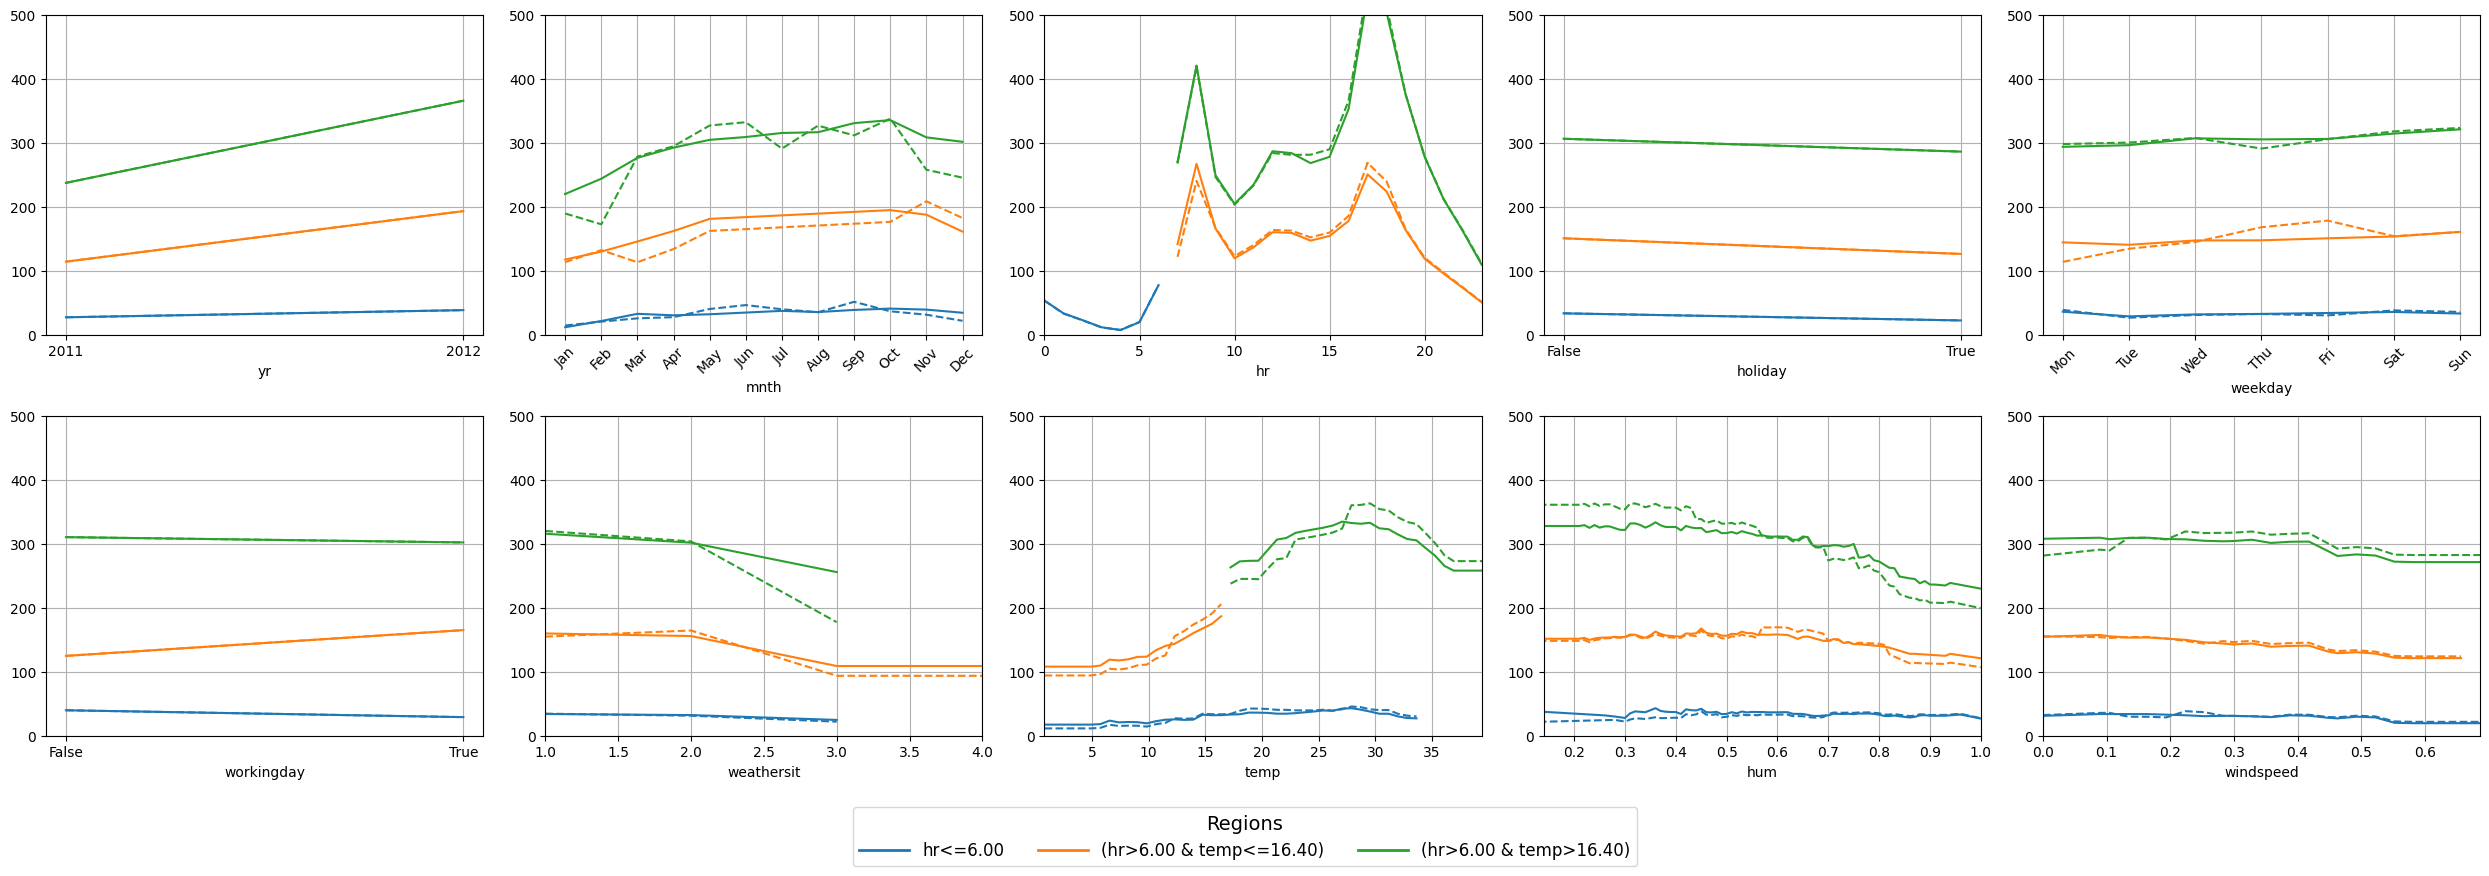

In [31]:
plot_regional_mplot_pdp(
    regional_decompositions=regional_decompositions,
    regional_backgrounds=regional_backgrounds,
    binned_features=binned_features,
    background=background,
    features=features,
    rules=rules,
    n_cols=5,
    ylim=(0, 500)
)
plt.savefig("../figures/bike_marg_cond_regional_all.pdf", bbox_inches='tight')

colors = plt.cm.tab10.colors
plot_region_legend(rules=rules, colors=colors, fig=plt.gcf(), max_cols=4, y_offset=-0.1)
plt.savefig("../figures/bike_marg_cond_regional_all_legend.pdf", bbox_inches='tight')

plt.show()  # now shows both plots and the legend

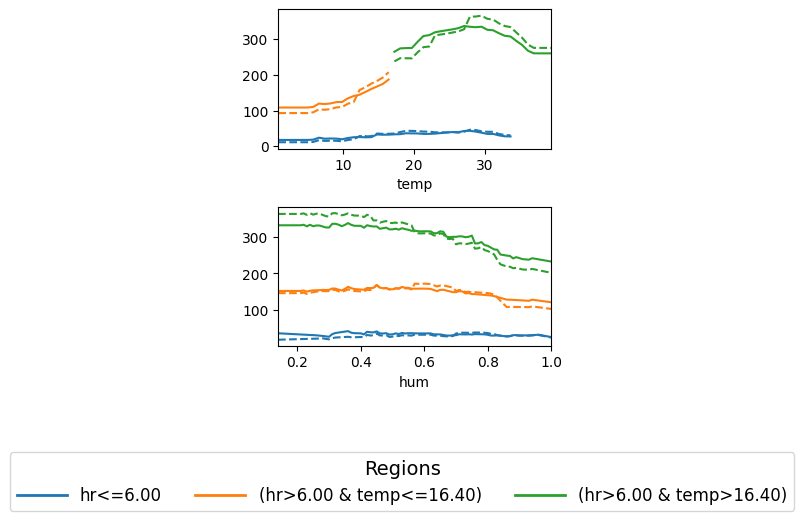

In [52]:
plot_regional_mplot_pdp(
    regional_decompositions=regional_decompositions,
    regional_backgrounds=regional_backgrounds,
    binned_features=binned_features,
    background=background,
    features=features,
    rules=rules,
    n_cols=1,
    feature_idxs=[7, 8],
    figsize=(3.5,5)
)

plt.savefig("../figures/bike_marg_cond_regional_main.pdf", bbox_inches='tight')
plt.tight_layout(rect=[0, 0.18, 1, 1])  # leave more space for the legend

plot_region_legend(rules=rules, colors=colors, fig=plt.gcf(), max_cols=4, y_offset=-0.05)
plt.savefig("../figures/bike_marg_cond_regional_main_legend.pdf", bbox_inches='tight')

plt.show()  # now shows both plots and the legend

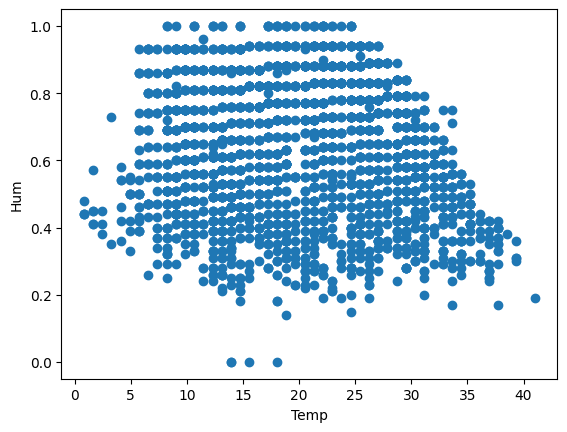

In [53]:
plt.scatter(larger_background[:, 7], larger_background[:, 8])
plt.xlabel("Temp")
plt.ylabel("Hum")
plt.show()